In [1]:
# --------------------------------------------------
# Project Root
# --------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import copy
import gc

import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.utils.config_loader import load_yaml

from src.dataset.feature_loader import (
    build_dataloader
)

from src.models.factorized.factorized_vae import (
    FactorizedVAE
)

from src.losses.total_loss import (
    TotalLoss
)

from src.trainers.memory_monitor import (
    MemoryMonitor
)

In [3]:
# --------------------------------------------------
# Memory Helper
# --------------------------------------------------

monitor = MemoryMonitor()

def print_ram():

    print(
        f"RAM Usage: {monitor.get_ram_gb():.2f} GB"
    )

print_ram()

RAM Usage: 0.28 GB


In [4]:
# --------------------------------------------------
# Config
# --------------------------------------------------

model_cfg = load_yaml(
    PROJECT_ROOT /
    "configs" /
    "model_config.yaml"
)

train_cfg = load_yaml(
    PROJECT_ROOT /
    "configs" /
    "train_config.yaml"
)

merged_cfg = copy.deepcopy(
    model_cfg
)

if "staged_activation" in train_cfg:

    merged_cfg[
        "staged_activation"
    ] = train_cfg[
        "staged_activation"
    ]

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"
)

print(device)

print_ram()

cpu
RAM Usage: 0.28 GB


In [5]:
# --------------------------------------------------
# Loader
# --------------------------------------------------

loader = build_dataloader(

    PROJECT_ROOT,

    split="train"
)

batch = next(iter(loader))

for k,v in batch.items():

    if torch.is_tensor(v):

        print(
            k,
            tuple(v.shape)
        )

logmel (1, 80, 27)
mr_mag_256 (1, 129, 53)
mr_mag_512 (1, 257, 27)
mr_mag_1024 (1, 513, 14)
magnitude (1, 513, 27)
if (1, 513, 27)
modgd (1, 513, 27)
phase_sin (1, 513, 27)
phase_cos (1, 513, 27)
lengths (1,)


In [6]:
# --------------------------------------------------
# Build Model
# --------------------------------------------------

model = FactorizedVAE(
    model_cfg
).to(device)

loss_fn = TotalLoss(
    merged_cfg
)

loss_fn.current_epoch = 1

loss_fn.total_epochs = (
    train_cfg["training"]["epochs"]
)

print(

    "Parameters:",

    sum(
        p.numel()
        for p in model.parameters()
    )
)

print_ram()

Parameters: 73217893
RAM Usage: 0.58 GB


In [7]:
# --------------------------------------------------
# Move Batch
# --------------------------------------------------

batch_gpu = {}

for k,v in batch.items():

    batch_gpu[k] = (

        v.to(device)

        if torch.is_tensor(v)

        else v
    )

print_ram()

RAM Usage: 0.58 GB


In [8]:
# --------------------------------------------------
# Encoder Test
# --------------------------------------------------

feature_groups = (

    model.group_manager
    .build_groups(batch_gpu)
)

latents, mu, logvar = (

    model.encode(
        feature_groups
    )
)

for name,z in latents.items():

    print(
        name,
        tuple(z.shape)
    )

print_ram()

content (1, 64)
speaker (1, 64)
environment (1, 96)
excitation (1, 32)
fidelity (1, 128)
RAM Usage: 1.76 GB


In [9]:
# --------------------------------------------------
# Decoder Core Test
# --------------------------------------------------

target_lengths = {

    "logmel":
        batch_gpu["logmel"].shape[-1],

    "mr_mag_256":
        batch_gpu["mr_mag_256"].shape[-1],

    "mr_mag_512":
        batch_gpu["mr_mag_512"].shape[-1],

    "magnitude":
        batch_gpu["magnitude"].shape[-1],

    "mr_mag_1024":
        batch_gpu["mr_mag_1024"].shape[-1]
}

hidden = model.decoder_core(

    latents["content"],
    latents["speaker"],
    latents["environment"],
    latents["excitation"],
    latents["fidelity"],

    target_lengths["logmel"]
)

print(
    hidden.shape
)

print_ram()

torch.Size([1, 27, 256])
RAM Usage: 1.76 GB


In [10]:
# --------------------------------------------------
# Full Forward Test
# --------------------------------------------------

outputs = model(
    batch_gpu
)

for k,v in outputs[
    "reconstructions"
].items():

    print(
        k,
        tuple(v.shape)
    )

print_ram()

logmel (1, 80, 27)
mr_mag_256 (1, 129, 53)
mr_mag_512 (1, 257, 27)
magnitude (1, 513, 27)
mr_mag_1024 (1, 513, 14)
if (1, 513, 27)
modgd (1, 513, 27)
phase_sin (1, 513, 27)
phase_cos (1, 513, 27)
RAM Usage: 2.86 GB


In [11]:
# --------------------------------------------------
# Shape Verification
# --------------------------------------------------

rows = []

for k in outputs[
    "reconstructions"
]:

    rows.append([

        k,

        tuple(
            outputs[
                "reconstructions"
            ][k].shape
        ),

        tuple(
            batch_gpu[k].shape
        )
    ])

pd.DataFrame(

    rows,

    columns=[
        "Feature",
        "Prediction",
        "Target"
    ]
)

,Feature,Prediction,Target
0,logmel,"(1, 80, 27)","(1, 80, 27)"
1,mr_mag_256,"(1, 129, 53)","(1, 129, 53)"
2,mr_mag_512,"(1, 257, 27)","(1, 257, 27)"
3,magnitude,"(1, 513, 27)","(1, 513, 27)"
4,mr_mag_1024,"(1, 513, 14)","(1, 513, 14)"
5,if,"(1, 513, 27)","(1, 513, 27)"
6,modgd,"(1, 513, 27)","(1, 513, 27)"
7,phase_sin,"(1, 513, 27)","(1, 513, 27)"
8,phase_cos,"(1, 513, 27)","(1, 513, 27)"


In [12]:
# --------------------------------------------------
# Activation Flags
# --------------------------------------------------

print(

    loss_fn.activation_flags()
)

{'phase': False, 'kl': False, 'orthogonality': False, 'tc': False}


In [13]:
# --------------------------------------------------
# Loss Test
# --------------------------------------------------

loss_dict = loss_fn(

    outputs,

    batch_gpu
)

loss_table = []

for k,v in loss_dict.items():

    loss_table.append(

        [k,float(v.detach())]
    )

pd.DataFrame(

    loss_table,

    columns=[
        "Metric",
        "Value"
    ]
)

,Metric,Value
0,reconstruction,5.540129
1,logmel_loss,0.195922
2,logmel_l1,0.173421
3,logmel_mse,0.045004
4,mr_mag_256_loss,0.178589
5,mr_mag_256_l1,0.159741
6,mr_mag_256_mse,0.037696
7,mr_mag_512_loss,0.184012
8,mr_mag_512_l1,0.164126
9,mr_mag_512_mse,0.039772


In [14]:
# --------------------------------------------------
# Backward Test
# --------------------------------------------------

loss = loss_dict["total"]

model.zero_grad(
    set_to_none=True
)

loss.backward()

print(
    "Backward Success"
)

print_ram()

Backward Success
RAM Usage: 2.58 GB


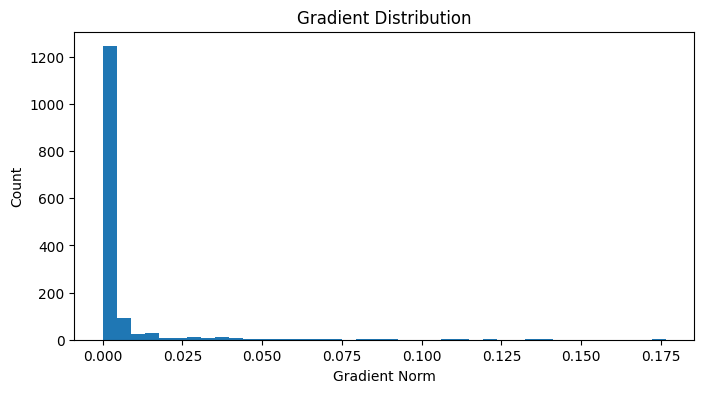

In [15]:
# --------------------------------------------------
# Gradient Histogram
# --------------------------------------------------

grads = []

for p in model.parameters():

    if p.grad is not None:

        grads.append(

            p.grad.norm()
            .item()
        )

plt.figure(
    figsize=(8,4)
)

plt.hist(
    grads,
    bins=40
)

plt.xlabel(
    "Gradient Norm"
)

plt.ylabel(
    "Count"
)

plt.title(
    "Gradient Distribution"
)

plt.show()

In [16]:
# --------------------------------------------------
# Latent Statistics
# --------------------------------------------------

rows = []

for name,z in latents.items():

    rows.append([

        name,

        z.mean().item(),

        z.std().item(),

        z.abs().max().item()
    ])

pd.DataFrame(

    rows,

    columns=[
        "Factor",
        "Mean",
        "Std",
        "AbsMax"
    ]
)

,Factor,Mean,Std,AbsMax
0,content,0.051586,1.052453,3.959796
1,speaker,-0.076947,1.149522,2.909051
2,environment,0.003259,1.080400,3.391017
3,excitation,0.214205,0.915986,2.289330
4,fidelity,0.007893,1.071726,3.187158


In [17]:
# --------------------------------------------------
# KL Statistics
# --------------------------------------------------

rows = []

for name in mu:

    kl = (

        -0.5

        *

        torch.mean(

            1
            +
            logvar[name]
            -
            mu[name]**2
            -
            logvar[name].exp()
        )
    )

    rows.append([

        name,

        float(
            kl.detach()
        )
    ])

pd.DataFrame(

    rows,

    columns=[
        "Factor",
        "KL"
    ]
)

,Factor,KL
0,content,0.122000
1,speaker,0.107518
2,environment,0.086015
3,excitation,0.127068
4,fidelity,0.103110


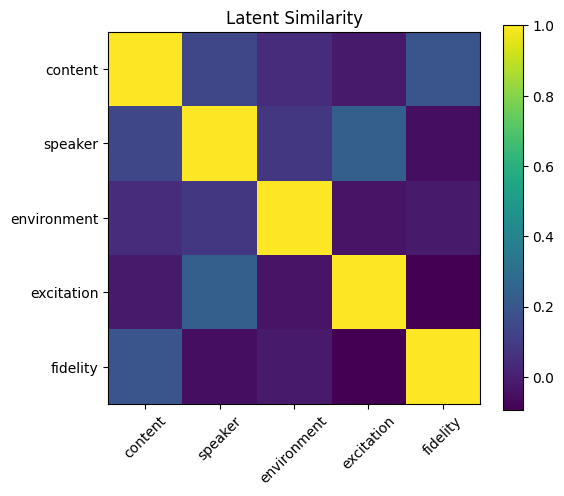

In [18]:
# --------------------------------------------------
# Latent Similarity Matrix
# --------------------------------------------------

import torch.nn.functional as F

names = list(
    latents.keys()
)

matrix = np.zeros(

    (
        len(names),
        len(names)
    )
)

for i in range(len(names)):

    for j in range(len(names)):

        z1 = latents[
            names[i]
        ]

        z2 = latents[
            names[j]
        ]

        common = min(

            z1.shape[-1],

            z2.shape[-1]
        )

        z1n = F.normalize(
            z1[:,:common],
            dim=-1
        )

        z2n = F.normalize(
            z2[:,:common],
            dim=-1
        )

        matrix[i,j] = (

            z1n*z2n

        ).sum(
            dim=-1
        ).mean().item()

plt.figure(
    figsize=(6,5)
)

plt.imshow(
    matrix
)

plt.xticks(
    range(len(names)),
    names,
    rotation=45
)

plt.yticks(
    range(len(names)),
    names
)

plt.colorbar()

plt.title(
    "Latent Similarity"
)

plt.show()

In [19]:
# --------------------------------------------------
# Fidelity Ablation
# --------------------------------------------------

latents_zero = {

    k:v.clone()

    for k,v

    in latents.items()
}

latents_zero[
    "fidelity"
] = torch.zeros_like(

    latents_zero[
        "fidelity"
    ]
)

recon_without_fidelity = (

    model.decode(

        latents_zero,

        target_lengths
    )
)

rows = []

for feature in [

    "logmel",

    "magnitude",

    "if"
]:

    diff = (

        outputs[
            "reconstructions"
        ][feature]

        -

        recon_without_fidelity[
            feature
        ]
    ).abs().mean()

    rows.append([

        feature,

        float(diff)
    ])

pd.DataFrame(

    rows,

    columns=[
        "Feature",
        "Fidelity Impact"
    ]
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_18532\185946541.py:61: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  float(diff)


,Feature,Fidelity Impact
0,logmel,0.013961
1,magnitude,0.013558
2,if,0.064033


In [20]:
# --------------------------------------------------
# Environment Ablation
# --------------------------------------------------

latents_zero = {

    k:v.clone()

    for k,v

    in latents.items()
}

latents_zero[
    "environment"
] = torch.zeros_like(

    latents_zero[
        "environment"
    ]
)

recon_without_env = (

    model.decode(

        latents_zero,

        target_lengths
    )
)

rows = []

for feature in [

    "logmel",

    "magnitude",

    "if"
]:

    diff = (

        outputs[
            "reconstructions"
        ][feature]

        -

        recon_without_env[
            feature
        ]
    ).abs().mean()

    rows.append([

        feature,

        float(diff)
    ])

pd.DataFrame(

    rows,

    columns=[
        "Feature",
        "Environment Impact"
    ]
)

,Feature,Environment Impact
0,logmel,0.012243
1,magnitude,0.010629
2,if,0.044153


In [21]:
loss_fn.current_epoch = 100
loss_fn.total_epochs = 300

print(
    loss_fn.activation_flags()
)

{'phase': True, 'kl': True, 'orthogonality': True, 'tc': True}


In [24]:
loss_fn.current_epoch = 100

loss_dict = loss_fn(
    outputs,
    batch_gpu
)

print(
    loss_dict["phase_derivative"]
)

print(
    loss_dict["von_mises"]
)

print(
    loss_dict["phase_continuity"]
)

tensor(0.5599, grad_fn=<MulBackward0>)
tensor(0.2492, grad_fn=<MulBackward0>)
tensor(0.1002, grad_fn=<MulBackward0>)


In [23]:
# # --------------------------------------------------
# # Cleanup
# # --------------------------------------------------

# del outputs
# del loss_dict
# del hidden

# gc.collect()

# print_ram()